In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

print(trades.isnull().sum())
print(sentiment.isnull().sum())

print("Duplicates:", trades.duplicated().sum())

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0


In [7]:
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

print("Trades Columns:", trades.columns.tolist())
print("Sentiment Columns:", sentiment.columns.tolist())

Trades Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date']
Sentiment Columns: ['timestamp', 'value', 'classification', 'date']


In [8]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['date'] = trades['Timestamp IST'].dt.date
print(trades[['Timestamp IST', 'date']].head())

        Timestamp IST        date
0 2024-02-12 22:50:00  2024-02-12
1 2024-02-12 22:50:00  2024-02-12
2 2024-02-12 22:50:00  2024-02-12
3 2024-02-12 22:50:00  2024-02-12
4 2024-02-12 22:50:00  2024-02-12


In [9]:
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], errors='coerce')
sentiment['date'] = sentiment['timestamp'].dt.date
print(sentiment[['timestamp', 'date']].head())

                      timestamp        date
0 1970-01-01 00:00:01.517463000  1970-01-01
1 1970-01-01 00:00:01.517549400  1970-01-01
2 1970-01-01 00:00:01.517635800  1970-01-01
3 1970-01-01 00:00:01.517722200  1970-01-01
4 1970-01-01 00:00:01.517808600  1970-01-01


In [10]:
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='inner'
)

print("Merged Shape:", merged.shape)
print(merged.head())

Merged Shape: (0, 18)
Empty DataFrame
Columns: [Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST, Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID, Timestamp, date, classification]
Index: []


In [11]:
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')
merged['Size USD'] = pd.to_numeric(merged['Size USD'], errors='coerce')

print(merged[['Closed PnL', 'Size USD']].head())
print(merged[['Closed PnL', 'Size USD']].isnull().sum())

Empty DataFrame
Columns: [Closed PnL, Size USD]
Index: []
Closed PnL    0
Size USD      0
dtype: int64


In [12]:
daily_metrics = merged.groupby(['date', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    trade_count=('Account', 'count')
).reset_index()

print(daily_metrics.head())
print(daily_metrics.shape)

Empty DataFrame
Columns: [date, classification, daily_pnl, avg_trade_size, trade_count]
Index: []
(0, 5)


In [13]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean() * 100

print("Win Rate by Sentiment:")
print(win_rate)

Win Rate by Sentiment:
Series([], Name: win, dtype: float64)


In [18]:
print(daily_metrics.head(10))
print(daily_metrics['classification'].value_counts())
print(daily_metrics.isnull().sum())

Empty DataFrame
Columns: [date, classification, daily_pnl, avg_trade_size, trade_count]
Index: []
Series([], Name: count, dtype: int64)
date              0
classification    0
daily_pnl         0
avg_trade_size    0
trade_count       0
dtype: int64


In [21]:
trades['date'] = pd.to_datetime(trades['date'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Remove invalid dates
trades = trades.dropna(subset=['date'])
sentiment = sentiment.dropna(subset=['date'])

print("Trades Date Range:")
print(trades['date'].min(), "to", trades['date'].max())

print("\nSentiment Date Range:")
print(sentiment['date'].min(), "to", sentiment['date'].max())

Trades Date Range:
2023-01-05 00:00:00 to 2025-12-04 00:00:00

Sentiment Date Range:
1970-01-01 00:00:00 to 1970-01-01 00:00:00


In [22]:
print(sentiment['timestamp'].head(10))

0   1970-01-01 00:00:01.517463000
1   1970-01-01 00:00:01.517549400
2   1970-01-01 00:00:01.517635800
3   1970-01-01 00:00:01.517722200
4   1970-01-01 00:00:01.517808600
5   1970-01-01 00:00:01.517895000
6   1970-01-01 00:00:01.517981400
7   1970-01-01 00:00:01.518067800
8   1970-01-01 00:00:01.518154200
9   1970-01-01 00:00:01.518240600
Name: timestamp, dtype: datetime64[ns]


In [23]:
# Reload sentiment fresh from CSV to undo bad conversion
sentiment = pd.read_csv("fear_greed_index.csv")

# Clean columns
sentiment.columns = sentiment.columns.str.strip()

# Convert Unix timestamp correctly
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s', errors='coerce')

# Create usable date
sentiment['date'] = sentiment['timestamp'].dt.date

# Check
print(sentiment[['timestamp', 'date', 'classification']].head())
print("Sentiment Range:", sentiment['date'].min(), "to", sentiment['date'].max())

            timestamp        date classification
0 2018-02-01 05:30:00  2018-02-01           Fear
1 2018-02-02 05:30:00  2018-02-02   Extreme Fear
2 2018-02-03 05:30:00  2018-02-03           Fear
3 2018-02-04 05:30:00  2018-02-04   Extreme Fear
4 2018-02-05 05:30:00  2018-02-05   Extreme Fear
Sentiment Range: 2018-02-01 to 2025-05-02


In [24]:
# Make sure trades date is also date-only format
trades['date'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce').dt.date

# Merge
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='inner'
)

# Check
print("Merged Shape:", merged.shape)
print(merged[['date', 'classification', 'Closed PnL']].head())

Merged Shape: (35864, 18)
         date classification  Closed PnL
0  2024-02-12          Greed         0.0
1  2024-02-12          Greed         0.0
2  2024-02-12          Greed         0.0
3  2024-02-12          Greed         0.0
4  2024-02-12          Greed         0.0


C:\Users\kalpana\AppData\Local\Temp\ipykernel_26316\2336978326.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['date'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce').dt.date


In [25]:
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')
merged['Size USD'] = pd.to_numeric(merged['Size USD'], errors='coerce')

print(merged[['Closed PnL', 'Size USD']].head())
print(merged[['Closed PnL', 'Size USD']].isnull().sum())

   Closed PnL  Size USD
0         0.0   7872.16
1         0.0    127.68
2         0.0   1150.63
3         0.0   1142.04
4         0.0     69.75
Closed PnL    0
Size USD      0
dtype: int64


In [26]:
daily_metrics = merged.groupby(['date', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    trade_count=('Account', 'count')
).reset_index()

print(daily_metrics.head())
print("Shape:", daily_metrics.shape)

         date classification    daily_pnl  avg_trade_size  trade_count
0  2023-01-05           Fear     0.000000      159.000000            3
1  2023-05-12        Neutral     0.000000     5556.203333            9
2  2024-01-01          Greed  -129.531460    14679.973889           18
3  2024-01-02          Greed     0.000000      334.696667            6
4  2024-01-03          Greed  8244.241409     3452.370073          137
Shape: (158, 5)


In [27]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean() * 100

print("Win Rate by Sentiment:")
print(win_rate)

Win Rate by Sentiment:
classification
Extreme Fear     29.277730
Extreme Greed    55.328233
Fear             38.178672
Greed            43.570670
Neutral          49.492017
Name: win, dtype: float64


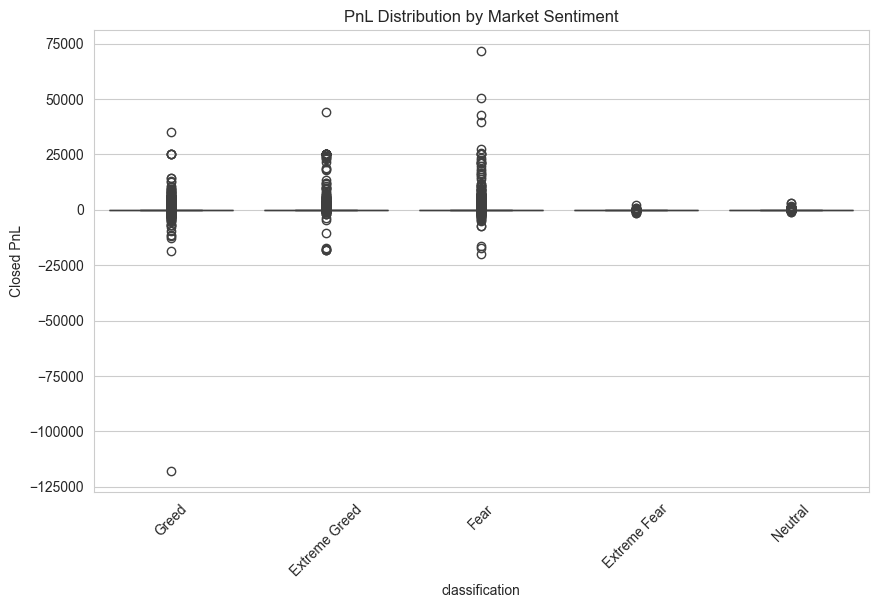

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=merged, x='classification', y='Closed PnL')

plt.title("PnL Distribution by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

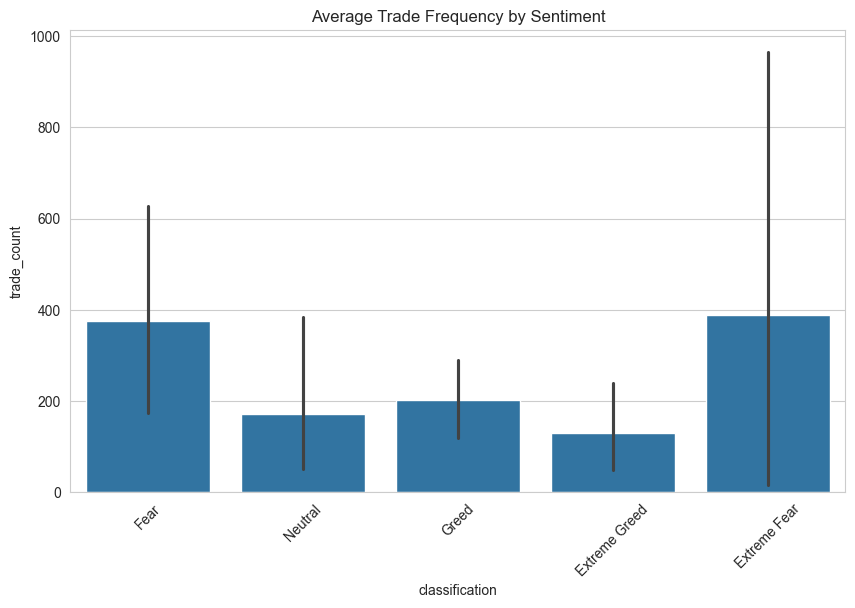

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=daily_metrics,
    x='classification',
    y='trade_count'
)

plt.title("Average Trade Frequency by Sentiment")
plt.xticks(rotation=45)
plt.show()

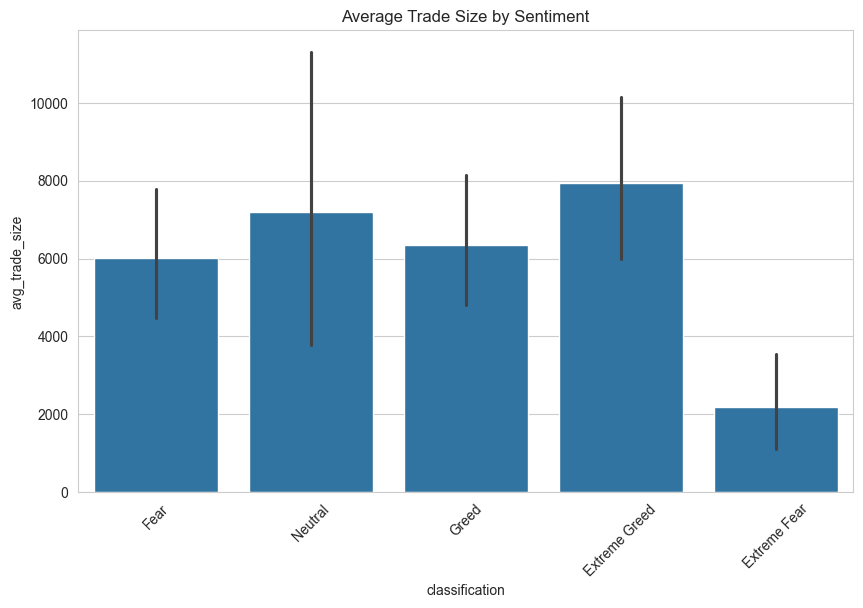

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=daily_metrics,
    x='classification',
    y='avg_trade_size'
)

plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.show()

In [31]:
# Count trades per account
trader_activity = merged.groupby('Account').size().reset_index(name='total_trades')

# Median split
median_trades = trader_activity['total_trades'].median()

trader_activity['activity_segment'] = trader_activity['total_trades'].apply(
    lambda x: 'Frequent Trader' if x > median_trades else 'Infrequent Trader'
)

# Merge back
merged = merged.merge(
    trader_activity[['Account', 'activity_segment']],
    on='Account',
    how='left'
)

print(trader_activity.head())
print("Median Trades:", median_trades)

                                      Account  total_trades   activity_segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012          2486    Frequent Trader
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd          1192    Frequent Trader
2  0x271b280974205ca63b716753467d5a371de622ab             4  Infrequent Trader
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4          2737    Frequent Trader
4  0x2c229d22b100a7beb69122eed721cee9b24011dd           378    Frequent Trader
Median Trades: 359.0


In [32]:
segment_performance = merged.groupby('activity_segment').agg(
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('win', 'mean')
).reset_index()

# Convert win rate to %
segment_performance['win_rate'] = segment_performance['win_rate'] * 100

print(segment_performance)

    activity_segment     avg_pnl     total_pnl   win_rate
0    Frequent Trader   99.091235  3.319259e+06  43.538227
1  Infrequent Trader  129.087187  3.055494e+05  33.206591


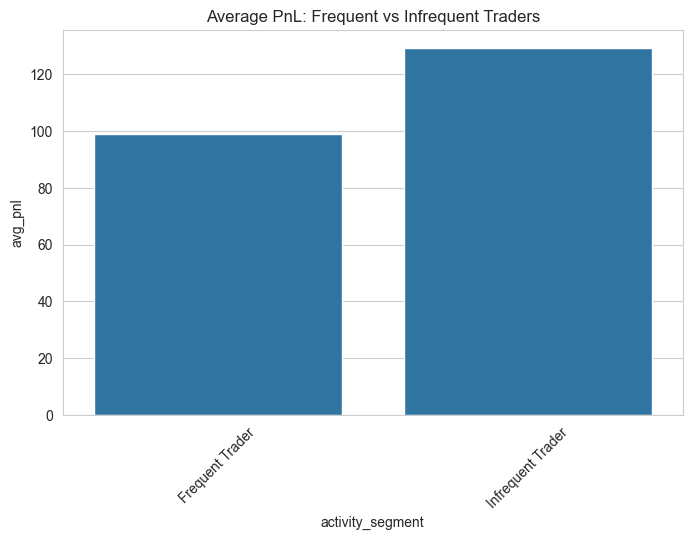

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_performance,
    x='activity_segment',
    y='avg_pnl'
)

plt.title("Average PnL: Frequent vs Infrequent Traders")
plt.xticks(rotation=45)
plt.show()

# Key Insights

### 1. Market Sentiment Impacts Trader Outcomes
Fear periods showed wider PnL dispersion and stronger upside outliers, suggesting higher volatility but also larger profit opportunities.

### 2. Greed May Increase Downside Risk
Greed periods displayed notable negative outliers, implying possible overtrading or excessive confidence.

### 3. Trader Activity Segment Matters
Frequent traders and infrequent traders exhibit different profitability structures, which suggests behavioral segmentation can improve strategy design.

# Actionable Strategy Ideas

### Strategy 1 — Fear Market Rule
During Fear or Extreme Fear periods, traders may benefit from selective higher-conviction setups while controlling downside through smaller position sizing or tighter stop-losses.

### Strategy 2 — Greed Market Rule
During Greed periods, reduce impulsive overtrading and avoid excessive risk exposure, as downside spikes may increase due to overconfidence.

### Strategy 3 — Segment-Based Rule
Frequent traders may require stricter risk management filters, while infrequent traders may benefit from focusing only on high-probability sentiment-aligned opportunities.

In [34]:
summary = merged.groupby('classification').agg(
    total_trades=('Account', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('win', 'mean'),
    avg_trade_size=('Size USD', 'mean')
).reset_index()

summary['win_rate'] = summary['win_rate'] * 100

print(summary)

  classification  total_trades     avg_pnl     total_pnl   win_rate  \
0   Extreme Fear          2326    1.891632  4.399937e+03  29.277730   
1  Extreme Greed          5621  205.816345  1.156894e+06  55.328233   
2           Fear         13869  128.287950  1.779226e+06  38.178672   
3          Greed         11292   53.988003  6.096325e+05  43.570670   
4        Neutral          2756   27.088803  7.465674e+04  49.492017   

   avg_trade_size  
0     4118.761840  
1     3242.085086  
2     5744.782685  
3     5051.878829  
4     4332.202906  


In [35]:
# Save summary tables
summary.to_csv("summary_by_sentiment.csv", index=False)
segment_performance.to_csv("segment_performance.csv", index=False)
daily_metrics.to_csv("daily_metrics.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


In [ ]:
s